In [28]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [29]:
df = sns.load_dataset('iris')

In [30]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [31]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [32]:
x = df.drop(columns=['species'])
y=df['species']

<Axes: >

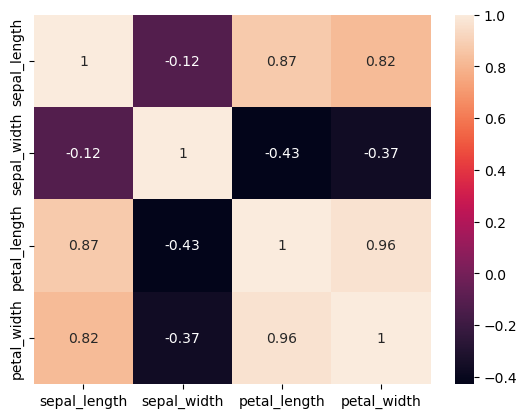

In [33]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='petal_width', ylabel='sepal_length'>

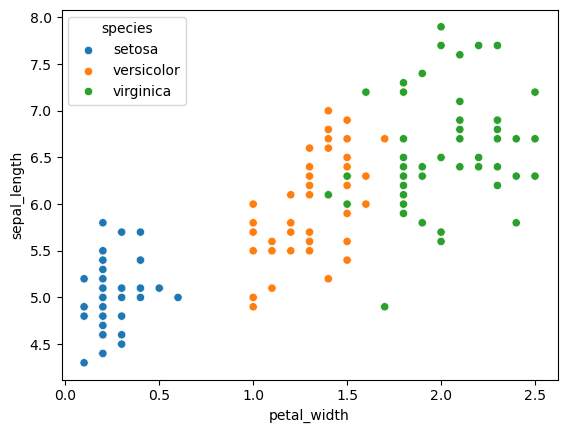

In [34]:
sns.scatterplot(x=df['petal_width'],y=df['sepal_length'],hue=df['species'])

In [35]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print('scaled')

scaled


In [37]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [38]:
from sklearn.svm import SVC 
linear_svm = SVC(
    kernel='linear', 
    C=1
)
linear_svm.fit(x_train,y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [39]:
y_pred_linear = linear_svm.predict(x_test)
acc1 = accuracy_score(y_test,y_pred_linear)
cm1 = confusion_matrix(y_test,y_pred_linear)
# prec1 = precision_score(y_test,y_pred_linear)
# rec1 = recall_score(y_test,y_pred_linear)
# f_1 = f1_score(y_test,y_pred_linear) 
print(classification_report(y_test,y_pred_linear))
print(cm1)
print(acc1)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
1.0


In [40]:
poly_svm = SVC(
    kernel='poly',
    degree=3 , 
    C=1 , 
    gamma='scale'
)
poly_svm.fit(x_train,y_train)

,C,1
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
y_pred_poly = poly_svm.predict(x_test)
acc2 = accuracy_score(y_test,y_pred_poly)
cm2 = confusion_matrix(y_test,y_pred_poly)
print(classification_report(y_test,y_pred_poly))
print(cm2)
print(acc2)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30

[[10  0  0]
 [ 0 10  0]
 [ 0  3  7]]
0.9


In [42]:
rbf_svm = SVC(
    kernel='rbf' , 
    C=1 , 
    gamma='scale'
)
rbf_svm.fit(x_train,y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [43]:
y_pred_rbf = poly_svm.predict(x_test)
acc3 = accuracy_score(y_test,y_pred_rbf)
cm3 = confusion_matrix(y_test,y_pred_rbf)
print(classification_report(y_test,y_pred_rbf))
print(cm3)
print(acc3)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.77      1.00      0.87        10
   virginica       1.00      0.70      0.82        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30

[[10  0  0]
 [ 0 10  0]
 [ 0  3  7]]
0.9


In [44]:
X_vis = x[['petal_width', 'sepal_length']]

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vis_scaler = StandardScaler()

X_vis_train_scaled = vis_scaler.fit_transform(X_vis_train)
X_vis_test_scaled = vis_scaler.transform(X_vis_test)

In [45]:
vis_linear = SVC(kernel='linear', C=1)
vis_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale')
vis_rbf = SVC(kernel='rbf', C=1, gamma='scale')

vis_linear.fit(X_vis_train_scaled, y_vis_train)
vis_poly.fit(X_vis_train_scaled, y_vis_train)
vis_rbf.fit(X_vis_train_scaled, y_vis_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [46]:
def plot_svm_boundary(model, X, y, title="SVM - Decision Boundary"):
    
    # Create mesh
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    # Predict each point in mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Convert class labels to numbers
    classes = model.classes_
    class_map = {label: i for i, label in enumerate(classes)}
    Z_num = np.vectorize(class_map.get)(Z)

    # Plot decision regions
    plt.figure(figsize=(10, 7))

    plt.contourf(
        xx,
        yy,
        Z_num,
        alpha=0.2,
        levels=np.arange(len(classes) + 1) - 0.5
    )

    # Plot data points
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette="viridis",
        s=60,
        edgecolor="black"
    )

    # Plot support vectors
    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vectors"
    )

    plt.xlabel("Standardized Feature 1")
    plt.ylabel("Standardized Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

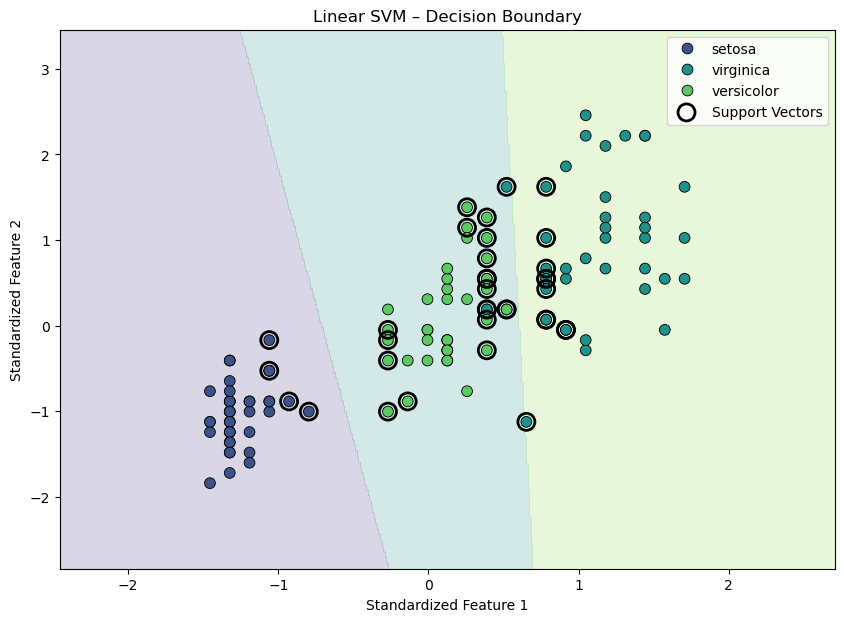

In [48]:
plot_svm_boundary(
    vis_linear,
    X_vis_train_scaled,
    y_vis_train,
    "Linear SVM – Decision Boundary"
)


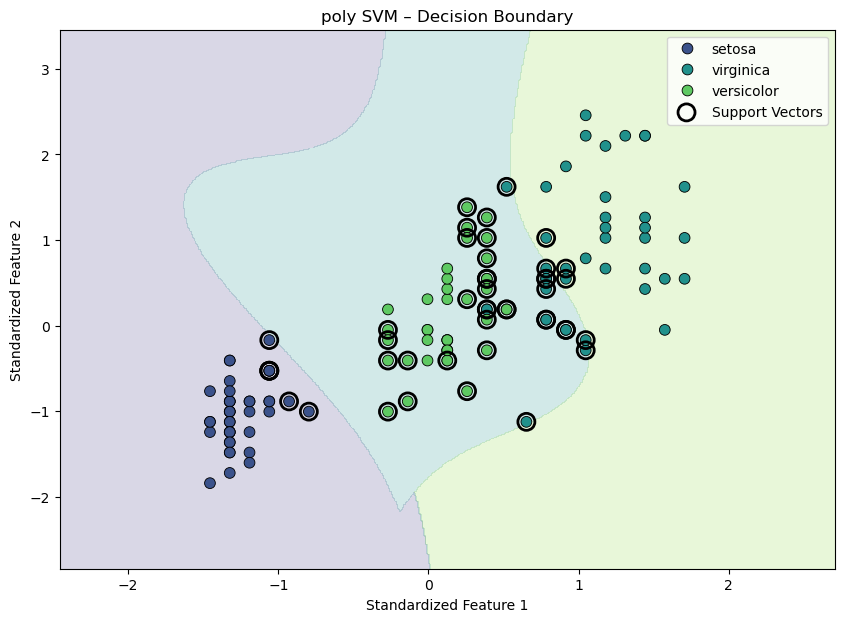

In [49]:
plot_svm_boundary(
    vis_poly,
    X_vis_train_scaled,
    y_vis_train,
    "poly SVM – Decision Boundary"
)


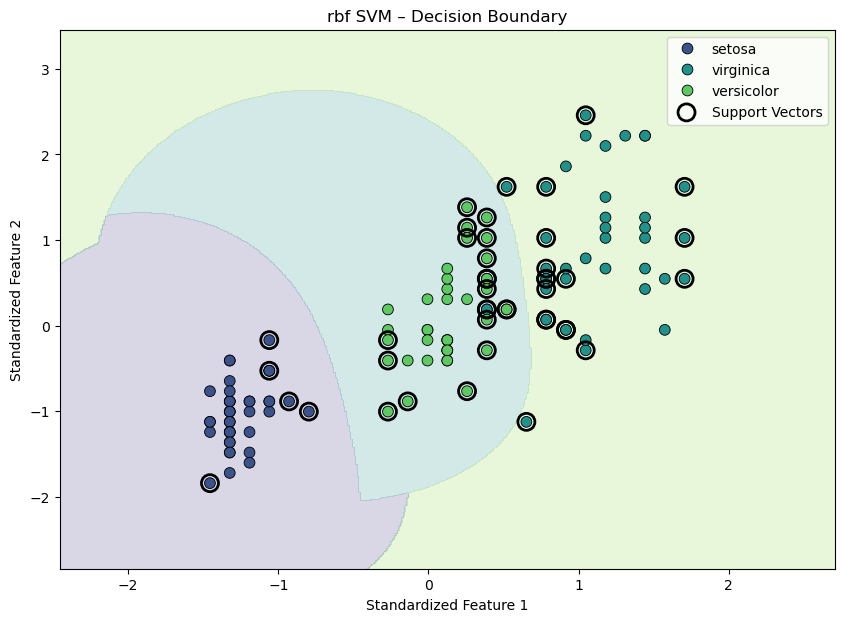

In [50]:
plot_svm_boundary(
    vis_rbf,
    X_vis_train_scaled,
    y_vis_train,
    "rbf SVM – Decision Boundary"
)


In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline 
svm_pipeline = Pipeline([
    ('svm' , SVC())
])

param_grid = {
    'svm__kernel':['linear','poly','rbf'], 
    'svm__C':[0.1,1,10,100], 
    'svm__degree':[2,3,4], 
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline , 
    param_grid = param_grid , 
    cv = 5 , 
    scoring= 'accuracy', 
    n_jobs=-1 
)

grid_search.fit(x_train,y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_) 

Best Parameters:
{'svm__C': 1, 'svm__degree': 2, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

Best Cross-Validation Score:
0.9833333333333332


In [ ]:
from sklearn.linear_model import LogisticRegression 
lg = LogisticRegression(max_iter=1000)
lg.fit(x)